# Analysis of the topic-filtered videos

This notebook **only reads** `data/output/videos_metadata/topic_filtered_videos.json`, the
output of stage 2 (`filter_videos.ipynb`). Nothing here re-runs the search, the name matching
or the keyword categorisation — it describes the set those steps produced.

One record in that file is one **search**: a `(year, company, CEO)` triple that was sent to the
YouTube API as `"[CEO] interview"` restricted to that calendar year. Every record in the file
kept at least one video, so "searches with 0 videos" are already absent — the averages below
are over the surviving searches, which is what makes them all ≥ 1.

A video carries `topics.categories`, the list of the five categories its title or description
matched. **A video can belong to several categories at once**, so the per-category counts sum
to more than the total number of videos, and the shares below are stated twice: as a share of
videos (they sum to > 100%) and as a share of category assignments (they sum to 100%, and are
what the pie chart draws).

## 1. Configuration

In [2]:
import json
import collections
from pathlib import Path
from statistics import mean, median

import isodate
import matplotlib.pyplot as plt

TOPIC_JSON = Path("data/output/videos_metadata/topic_filtered_videos.json")

# Same display order as stage 2, so the tables here line up with the ones there.
CATEGORY_ORDER = ["DEI", "environment", "worker_governance",
                  "customer_responsibility", "tech_responsibility"]

# Short labels for charts — the keyword files' own labels are too long for a legend.
CATEGORY_LABEL = {
    "DEI":                     "Diversity, Equity & Inclusion",
    "environment":             "Environmental sustainability",
    "worker_governance":       "Worker welfare & governance",
    "customer_responsibility": "Customer responsibility",
    "tech_responsibility":     "Innovation & tech responsibility",
}

YEARS = list(range(2020, 2026))

## 2. Load and flatten

The file is nested (search → videos), but every question below is asked *of videos*, so it is
flattened once into one row per video, carrying the search it came from. `search` is the
`(year, company, CEO)` triple rather than `(year, company)` alone: twelve companies changed CEO
mid-window and were searched once per CEO, so the pair is not unique but the triple is.

Durations are parsed here as well — `contentDetails.duration` is ISO-8601 (`PT6M58S`) and
`isodate` turns it into seconds. A video with no parseable duration keeps `seconds = None` and
is excluded from the duration averages only; it still counts everywhere else.

In [3]:
records = json.loads(TOPIC_JSON.read_text(encoding="utf-8"))

rows = []
for rec in records:
    for video in rec["videos"]:
        try:
            seconds = isodate.parse_duration(
                (video.get("contentDetails") or {})["duration"]).total_seconds()
        except Exception:
            seconds = None
        rows.append({
            "video_id":   video["video_id"],
            "year":       rec["year"],
            "company":    rec["company"],
            "ceo":        rec["canonical_ceo"],
            "search":     (rec["year"], rec["company"], rec["canonical_ceo"]),
            "categories": video["topics"]["categories"],
            "seconds":    seconds,
        })

# Videos of each category. A video appears in every category it matched.
per_category = {c: [r for r in rows if c in r["categories"]] for c in CATEGORY_ORDER}

print(f"{len(records):,} searches · {len(rows):,} videos · "
      f"{len({r['ceo'] for r in rows}):,} CEOs")

1,594 searches · 9,327 videos · 621 CEOs


## 3. Totals and category shares

`Total videos` counts rows, not distinct YouTube IDs. A handful of videos are returned by two
different searches — a joint interview with two Fortune 500 CEOs is found under both names —
so the distinct-ID count is printed alongside as a check on the size of that overlap.

In [4]:
n_videos = len(rows)
n_unique_ids = len({r["video_id"] for r in rows})
n_assignments = sum(len(v) for v in per_category.values())

print(f"Total videos                 : {n_videos:>8,}")
print(f"  distinct YouTube IDs       : {n_unique_ids:>8,} "
      f"({n_videos - n_unique_ids} found by two different searches)")
print(f"Total category assignments   : {n_assignments:>8,} "
      f"({n_assignments / n_videos:.2f} categories per video)")
print()

header = f"{'Category':<32}{'Videos':>8}{'% of videos':>14}{'% of assign.':>14}"
print(header)
print("-" * len(header))
for category in sorted(CATEGORY_ORDER, key=lambda c: -len(per_category[c])):
    videos = per_category[category]
    print(f"{CATEGORY_LABEL[category]:<32}{len(videos):>8,}"
          f"{len(videos) / n_videos:>13.1%}"
          f"{len(videos) / n_assignments:>14.1%}")
print("-" * len(header))
print(f"{'(videos, deduplicated)':<32}{n_videos:>8,}{1:>13.0%}")

Total videos                 :    9,327
  distinct YouTube IDs       :    9,265 (62 found by two different searches)
Total category assignments   :   13,942 (1.49 categories per video)

Category                          Videos   % of videos  % of assign.
--------------------------------------------------------------------
Worker welfare & governance        4,056        43.5%         29.1%
Innovation & tech responsibility   3,716        39.8%         26.7%
Customer responsibility            3,300        35.4%         23.7%
Diversity, Equity & Inclusion      1,478        15.8%         10.6%
Environmental sustainability       1,392        14.9%         10.0%
--------------------------------------------------------------------
(videos, deduplicated)             9,327         100%


## 4. Chart styling

Both charts share one palette so a category is the same colour in the pie and in the bars.
The five hues are the first five slots of a categorical palette validated for colour-vision
deficiency: they clear the adjacent-pair separation gates that stacked bars and legends rely
on. Assignment is **fixed per category**, never by rank, so re-sorting the pie does not repaint
anything.

Three of the five sit below 3:1 contrast against the light chart surface, which is why both
charts carry visible labels — percentages inside the pie slices, a legend with counts — rather
than relying on colour alone to identify a category.

In [6]:
# Categorical palette — fixed per category, assigned by identity and never by rank.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
COLOR = dict(zip(CATEGORY_ORDER, SERIES))

SURFACE   = "#fcfcfb"   # chart surface
INK       = "#0b0b0b"   # primary text
INK_SOFT  = "#52514e"   # secondary text
MUTED     = "#898781"   # axis labels
GRID      = "#e1e0d9"   # hairline gridline
BASELINE  = "#c3c2b7"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
})

## 5. Videos per category — pie

Slices and legend both run **largest to smallest**, starting at 12 o'clock and going clockwise,
so the reading order of the legend is the reading order of the chart.

The slices are shares of *category assignments*, not of videos: a video in two categories
contributes to two slices, and only the assignment denominator makes the five parts sum to a
whole. The legend carries the absolute video count for each category so the underlying number
is never lost to the normalisation.

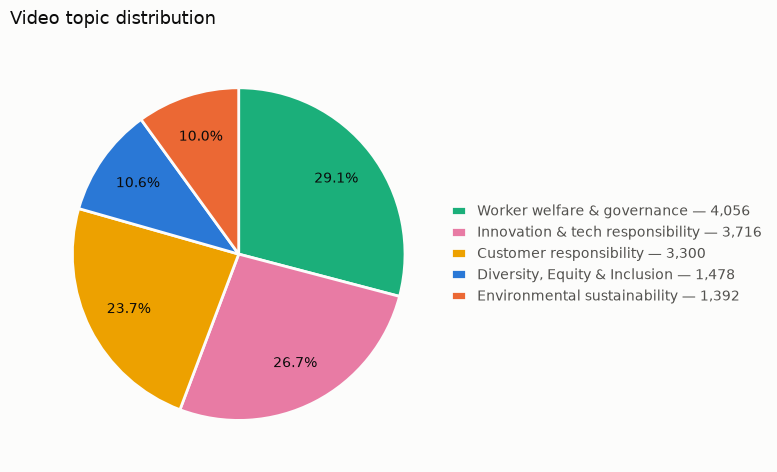

In [9]:
ordered = sorted(CATEGORY_ORDER, key=lambda c: -len(per_category[c]))
sizes = [len(per_category[c]) for c in ordered]

fig, ax = plt.subplots(figsize=(8.4, 5.4))
ax.pie(
    sizes,
    colors=[COLOR[c] for c in ordered],
    startangle=90, counterclock=False,          # largest first, clockwise from 12 o'clock
    wedgeprops=dict(edgecolor=SURFACE, linewidth=2),   # 2px surface gap between slices
    autopct=lambda pct: f"{pct:.1f}%",
    pctdistance=0.74,
    textprops=dict(color=INK, fontsize=10),
)
ax.legend(
    [f"{CATEGORY_LABEL[c]} — {len(per_category[c]):,}" for c in ordered],
    loc="center left", bbox_to_anchor=(0.98, 0.5),
    frameon=False, fontsize=10, labelcolor=INK_SOFT, handlelength=1.1,
)
ax.set_title("Video topic distribution", color=INK, fontsize=13,
             loc="left", x=-0.05, pad=16)
ax.set_aspect("equal")
plt.show()

## 6. Per-category reach

Three measures per category:

- **CEOs with 1+ video** — how many distinct CEOs the category reaches, out of the 621 in the
  file. This counts CEOs, not searches, so a CEO found in four different years counts once.
- **Avg videos per search** — total videos in the category divided by the number of searches
  that returned **at least one video of that category**. Searches with zero videos in the
  category are excluded from the denominator, which is what the "(over N searches)" note
  records; every average is therefore ≥ 1 and describes a typical *productive* search.
- **Top CEO** — the single CEO with the most videos in the category. Ties are reported rather
  than broken arbitrarily.

In [11]:
print(f"{'Category':<32}{'CEOs':>7}{'Searches':>11}{'Avg/search':>13}   Top CEO")
print("-" * 96)
for category in CATEGORY_ORDER:
    videos = per_category[category]
    ceos = {r["ceo"] for r in videos}
    searches = {r["search"] for r in videos}

    counts = collections.Counter(r["ceo"] for r in videos)
    best = max(counts.values())
    leaders = sorted(name for name, n in counts.items() if n == best)
    top = f"{leaders[0]} ({best} videos)"
    if len(leaders) > 1:
        top += f"  [tied with {', '.join(leaders[1:])}]"

    print(f"{CATEGORY_LABEL[category]:<32}{len(ceos):>7,}{len(searches):>11,}"
          f"{len(videos) / len(searches):>13.2f}   {top}")
print("-" * 96)

all_searches = {r["search"] for r in rows}
print(f"{'All videos':<32}{len({r['ceo'] for r in rows}):>7,}{len(all_searches):>11,}"
      f"{len(rows) / len(all_searches):>13.2f}")

Category                           CEOs   Searches   Avg/search   Top CEO
------------------------------------------------------------------------------------------------
Diversity, Equity & Inclusion       340        692         2.14   Andrew Wilson (49 videos)
Environmental sustainability        324        639         2.18   Larry Fink (70 videos)
Worker welfare & governance         501      1,140         3.56   Marc Benioff (93 videos)
Customer responsibility             456      1,065         3.10   Andy Jassy (67 videos)  [tied with Doug McMillon]
Innovation & tech responsibility    424        923         4.03   Jensen Huang (159 videos)
------------------------------------------------------------------------------------------------
All videos                          621      1,594         5.85


### The most prolific CEO per category

The same numbers as the last column above, stated on their own line — for each category, the
one CEO who holds the most videos in it, and what share of the category that is.

In [10]:
for category in CATEGORY_ORDER:
    videos = per_category[category]
    counts = collections.Counter(r["ceo"] for r in videos)
    best = max(counts.values())
    leaders = sorted(name for name, n in counts.items() if n == best)
    share = best / len(videos)
    for name in leaders:
        years_seen = sorted({r["year"] for r in videos if r["ceo"] == name})
        company = next(r["company"] for r in videos if r["ceo"] == name)
        print(f"{CATEGORY_LABEL[category]:<32} {name} ({company}) — {best} videos "
              f"({share:.1%} of the category), years {years_seen[0]}–{years_seen[-1]}")

Diversity, Equity & Inclusion    Andrew Wilson (Electronic Arts) — 49 videos (3.3% of the category), years 2021–2025
Environmental sustainability     Larry Fink (BlackRock) — 70 videos (5.0% of the category), years 2020–2025
Worker welfare & governance      Marc Benioff (Salesforce) — 93 videos (2.3% of the category), years 2020–2025
Customer responsibility          Andy Jassy (Amazon) — 67 videos (2.0% of the category), years 2021–2025
Customer responsibility          Doug McMillon (Walmart) — 67 videos (2.0% of the category), years 2020–2025
Innovation & tech responsibility Jensen Huang (Nvidia) — 159 videos (4.3% of the category), years 2020–2025


## 7. Video duration

Mean and median are both printed because they disagree by a lot: the mean is pulled up by
multi-hour conference sessions and full earnings-call streams, while the median describes the
ordinary clip — a news segment of a few minutes. The median is the number to quote when
describing a typical video; the mean is the one that matters for anything proportional to
total watch time.

In [12]:
def hms(seconds: float) -> str:
    """Seconds as h:mm:ss, dropping the hour when there isn't one."""
    seconds = int(round(seconds))
    hours, rest = divmod(seconds, 3600)
    minutes, secs = divmod(rest, 60)
    return f"{hours}:{minutes:02d}:{secs:02d}" if hours else f"{minutes}:{secs:02d}"

def durations(videos):
    return [r["seconds"] for r in videos if r["seconds"] is not None]

overall = durations(rows)
print(f"Average duration, all videos : {hms(mean(overall)):>9}   "
      f"(median {hms(median(overall))}, longest {hms(max(overall))})")
if len(overall) < len(rows):
    print(f"  videos with no duration    : {len(rows) - len(overall):,}")
print()

print(f"{'Category':<32}{'Average':>10}{'Median':>10}{'Longest':>12}")
print("-" * 64)
for category in CATEGORY_ORDER:
    secs = durations(per_category[category])
    print(f"{CATEGORY_LABEL[category]:<32}{hms(mean(secs)):>10}"
          f"{hms(median(secs)):>10}{hms(max(secs)):>12}")

Average duration, all videos :     16:11   (median 5:36, longest 11:55:00)

Category                           Average    Median     Longest
----------------------------------------------------------------
Diversity, Equity & Inclusion        19:59      6:54     6:17:19
Environmental sustainability         17:55      7:14     5:55:45
Worker welfare & governance          16:55      5:43     6:17:19
Customer responsibility              16:46      5:48    11:55:00
Innovation & tech responsibility     17:28      6:56     8:37:35


## 8. Topic mix per year — stacked bars

One bar per year, split into the five categories. Bar **height** is the number of category
assignments in that year, so a year in which videos matched more categories each stands taller
than its video count alone would suggest — the note under the title states both.

Stacked rather than grouped because the question is the *mix* within a year, and stacking keeps
each year readable as one object. The segments are separated by a 2px gap in the surface colour
so adjacent colours never touch, and the legend runs in the same fixed category order as
everywhere else.

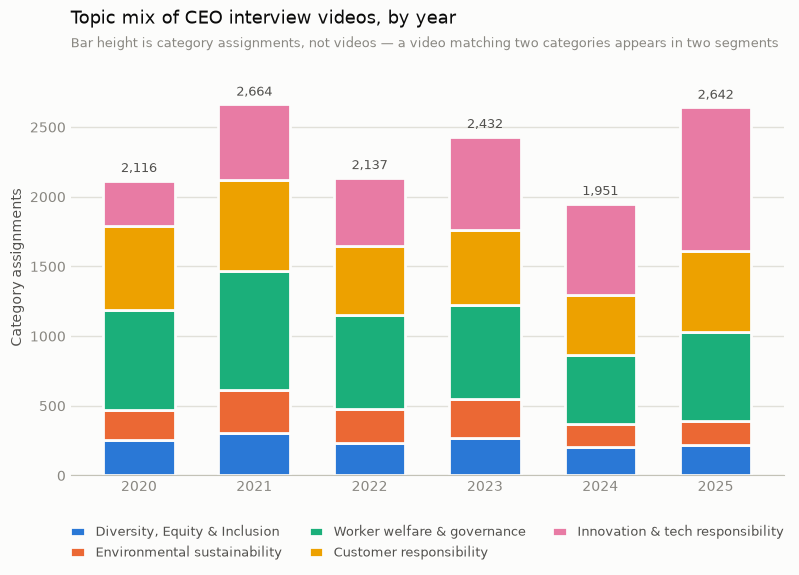

Year    Videos  Assign.         DEI  Environ.    Worker  Customer      Tech
-------------------------------------------------------------------------
2020     1,450    2,116         258       214       718       601       325
2021     1,747    2,664         302       309       854       656       543
2022     1,446    2,137         234       242       676       494       491
2023     1,646    2,432         266       282       677       534       673
2024     1,288    1,951         202       171       493       429       656
2025     1,750    2,642         216       174       638       586     1,028


In [13]:
counts_by_year = {
    category: [sum(1 for r in per_category[category] if r["year"] == year) for year in YEARS]
    for category in CATEGORY_ORDER
}
videos_by_year = collections.Counter(r["year"] for r in rows)

fig, ax = plt.subplots(figsize=(9.2, 5.4))

bottom = [0] * len(YEARS)
for category in CATEGORY_ORDER:
    values = counts_by_year[category]
    ax.bar(YEARS, values, bottom=bottom, width=0.62,
           color=COLOR[category], label=CATEGORY_LABEL[category],
           edgecolor=SURFACE, linewidth=2, zorder=2)          # 2px gap between segments
    bottom = [b + v for b, v in zip(bottom, values)]

# Total assignments above each bar — the one number that has no segment to sit in.
for year, total in zip(YEARS, bottom):
    ax.text(year, total + 40, f"{total:,}", ha="center", va="bottom",
            color=INK_SOFT, fontsize=9)

ax.set_axisbelow(True)
ax.yaxis.grid(True, color=GRID, linewidth=1)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color(BASELINE)
ax.tick_params(colors=MUTED, length=0)
ax.set_xticks(YEARS)
ax.set_ylim(0, max(bottom) * 1.12)
ax.set_ylabel("Category assignments", color=INK_SOFT)

ax.set_title("Topic mix of CEO interview videos, by year", color=INK, fontsize=13,
             loc="left", pad=26)
ax.text(0, 1.03, "Bar height is category assignments, not videos — a video matching two "
        "categories appears in two segments",
        transform=ax.transAxes, color=MUTED, fontsize=9)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.09), ncol=3,
          frameon=False, fontsize=9.5, labelcolor=INK_SOFT, handlelength=1.1)
plt.show()

SHORT = {"DEI": "DEI", "environment": "Environ.", "worker_governance": "Worker",
         "customer_responsibility": "Customer", "tech_responsibility": "Tech"}

print(f"{'Year':<6}{'Videos':>8}{'Assign.':>9}  " +
      "".join(f"{SHORT[c]:>10}" for c in CATEGORY_ORDER))
print("-" * 73)
for i, year in enumerate(YEARS):
    print(f"{year:<6}{videos_by_year[year]:>8,}{bottom[i]:>9,}  " +
          "".join(f"{counts_by_year[c][i]:>10,}" for c in CATEGORY_ORDER))

Diversity, Equity & Inclusion: slope = -0.0092 per year, intercept = 18.6991
Environmental sustainability: slope = -0.0105 per year, intercept = 21.4810
Worker welfare & governance: slope = -0.0294 per year, intercept = 59.8054
Customer responsibility: slope = -0.0155 per year, intercept = 31.7095
Innovation & tech responsibility: slope = 0.0709 per year, intercept = -142.9847


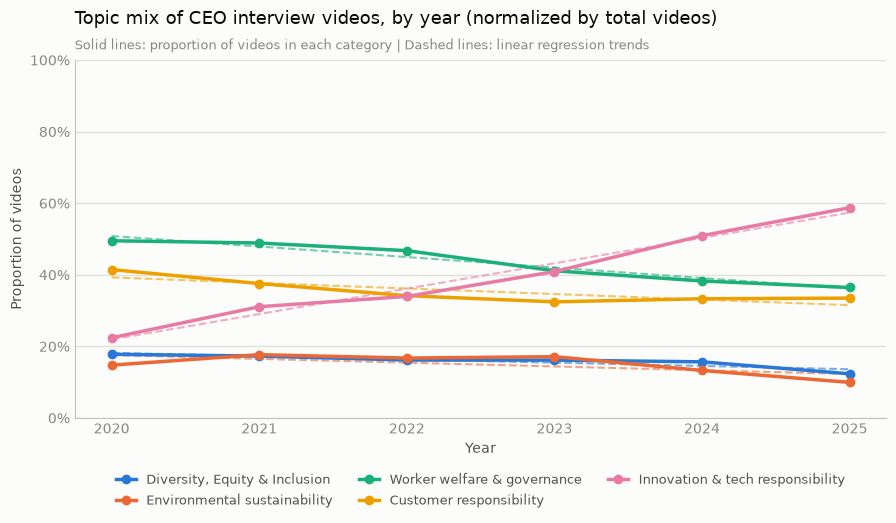


PROPORTIONS (percentage of videos in each category per year)
Year  Total VideosTotal Assign.         DEI  Environ.    Worker  Customer      Tech
--------------------------------------------------------------------------------
2020         1,450        2,116       17.8%     14.8%     49.5%     41.4%     22.4%
2021         1,747        2,664       17.3%     17.7%     48.9%     37.6%     31.1%
2022         1,446        2,137       16.2%     16.7%     46.7%     34.2%     34.0%
2023         1,646        2,432       16.2%     17.1%     41.1%     32.4%     40.9%
2024         1,288        1,951       15.7%     13.3%     38.3%     33.3%     50.9%
2025         1,750        2,642       12.3%      9.9%     36.5%     33.5%     58.7%

RAW COUNTS (for reference)
Year  Total VideosTotal Assign.         DEI  Environ.    Worker  Customer      Tech
--------------------------------------------------------------------------------
2020         1,450        2,116         258       214       718       601   

In [18]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Calculate normalized values (proportion of videos in each category per year)
normalized_counts = {}
for category in CATEGORY_ORDER:
    normalized_counts[category] = []
    for i, year in enumerate(YEARS):
        total_videos = videos_by_year[year]
        if total_videos > 0:
            proportion = counts_by_year[category][i] / total_videos
            normalized_counts[category].append(proportion)
        else:
            normalized_counts[category].append(0)

# Create the plot
fig, ax = plt.subplots(figsize=(9.2, 5.4))

# Plot each category as a line with regression on normalized data
for category in CATEGORY_ORDER:
    values = normalized_counts[category]
    
    # Plot the actual data points as a line (proportions)
    ax.plot(YEARS, values, 
            color=COLOR[category], 
            label=CATEGORY_LABEL[category],
            marker='o', 
            linewidth=2.5, 
            markersize=6,
            zorder=2)
    
    # Calculate and plot linear regression on proportions
    X = np.array(YEARS).reshape(-1, 1)
    y = np.array(values)
    
    # Fit linear regression
    reg = LinearRegression().fit(X, y)
    trend_line = reg.predict(X)
    
    # Plot trend line (dashed, slightly transparent)
    ax.plot(YEARS, trend_line, 
            color=COLOR[category], 
            linestyle='--', 
            linewidth=1.5, 
            alpha=0.6,
            zorder=1)
    
    # Optional: Print slope and intercept for each category
    slope = reg.coef_[0]
    intercept = reg.intercept_
    print(f"{CATEGORY_LABEL[category]}: slope = {slope:.4f} per year, "
          f"intercept = {intercept:.4f}")

# Customize the plot
ax.set_axisbelow(True)
ax.yaxis.grid(True, color=GRID, linewidth=1)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color(BASELINE)
ax.spines["left"].set_color(BASELINE)
ax.tick_params(colors=MUTED, length=0)
ax.set_xticks(YEARS)
ax.set_xlabel("Year", color=INK_SOFT)
ax.set_ylabel("Proportion of videos", color=INK_SOFT)

# Set y-axis limits (0 to 1 for proportions)
ax.set_ylim(0, 1.0)

# Format y-axis as percentages
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Title and annotations
ax.set_title("Topic mix of CEO interview videos, by year (normalized by total videos)", 
             color=INK, fontsize=13, loc="left", pad=26)

# Add note about normalization
ax.text(0, 1.03, 
        "Solid lines: proportion of videos in each category | Dashed lines: linear regression trends",
        transform=ax.transAxes, 
        color=MUTED, 
        fontsize=9)

# Legend
ax.legend(loc="upper center", 
          bbox_to_anchor=(0.5, -0.12), 
          ncol=3,
          frameon=False, 
          fontsize=9.5, 
          labelcolor=INK_SOFT, 
          handlelength=1.5)

plt.tight_layout()
plt.show()

# Print data table with proportions
print("\n" + "=" * 80)
print("PROPORTIONS (percentage of videos in each category per year)")
print("=" * 80)
print(f"{'Year':<6}{'Total Videos':>12}{'Total Assign.':>13}  " +
      "".join(f"{SHORT[c]:>10}" for c in CATEGORY_ORDER))
print("-" * 80)
for i, year in enumerate(YEARS):
    total_videos = videos_by_year[year]
    proportions = [f"{normalized_counts[c][i]:.1%}" for c in CATEGORY_ORDER]
    print(f"{year:<6}{total_videos:>12,}{bottom[i]:>13,}  " +
          "".join(f"{p:>10}" for p in proportions))

# Also print raw counts for comparison
print("\n" + "=" * 80)
print("RAW COUNTS (for reference)")
print("=" * 80)
print(f"{'Year':<6}{'Total Videos':>12}{'Total Assign.':>13}  " +
      "".join(f"{SHORT[c]:>10}" for c in CATEGORY_ORDER))
print("-" * 80)
for i, year in enumerate(YEARS):
    print(f"{year:<6}{videos_by_year[year]:>12,}{bottom[i]:>13,}  " +
          "".join(f"{counts_by_year[c][i]:>10,}" for c in CATEGORY_ORDER))

In [19]:
# Print total videos per year
print("=" * 50)
print("TOTAL VIDEOS PER YEAR")
print("=" * 50)
print(f"{'Year':<10}{'Total Videos':>15}")
print("-" * 50)

# Sort years for clean output
for year in sorted(YEARS):
    total = videos_by_year[year]
    print(f"{year:<10}{total:>15,}")

print("-" * 50)
print(f"{'Total':<10}{sum(videos_by_year.values()):>15,}")
print("=" * 50)

TOTAL VIDEOS PER YEAR
Year         Total Videos
--------------------------------------------------
2020                1,450
2021                1,747
2022                1,446
2023                1,646
2024                1,288
2025                1,750
--------------------------------------------------
Total               9,327
